In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,roc_curve,auc

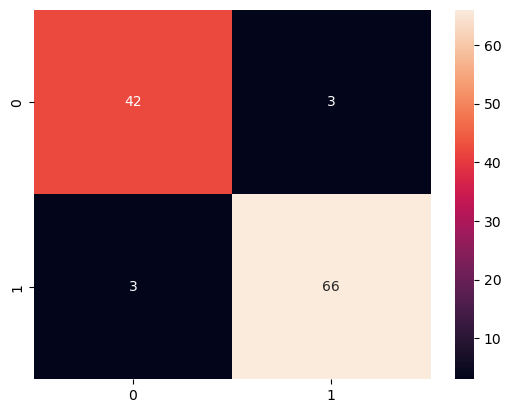

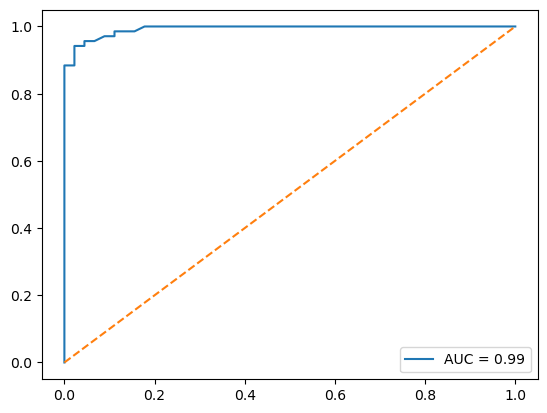

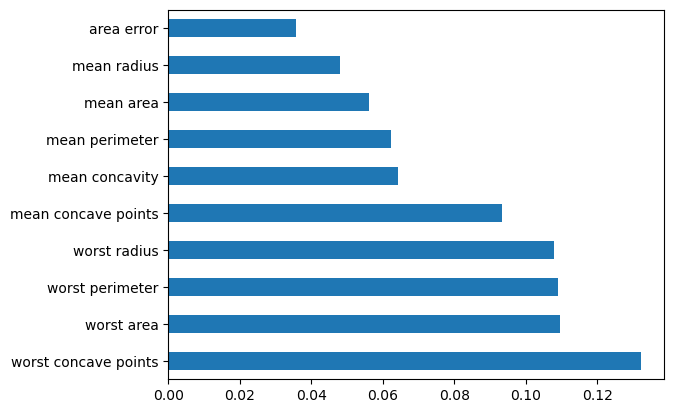

In [10]:
data = load_breast_cancer()
X = pd.DataFrame(data=data.data, columns=data.feature_names)
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True, fmt='d')
plt.show()

fpr,tpr,_ = roc_curve(y_test,y_prob[:,1])
roc_auc = auc(fpr,tpr)
plt.plot(fpr,tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.show()

importance = model.feature_importances_
feat = pd.Series(importance, index=X.columns).sort_values(ascending=False)
feat.head(10).plot(kind='barh')
plt.show()